# Jito Block Auction Competitiveness Analysis - Executive Notebook

## Bottom line

My read is: **Jito is broadly competitive in the aggregate, but not fully competitive at the validator-efficiency level.** At the market level, MEV allocation largely follows stake and leader opportunity. That means raw concentration alone is not enough to call the auction broken.

The stronger result is one layer deeper: a set of validators continues to earn more MEV per produced block and per scheduled leader slot out of sample. In other words, stake explains a lot of the market-wide allocation, but it does not explain away the persistent validator-level edge.

The best-supported mechanism in the data is **order-flow/searcher-flow advantage**. Execution quality and infra/reliability also help explain the pattern, while entity/vertical integration is still harder to measure cleanly with the current public endpoints.

This notebook is the short shareable deliverable. It keeps the key code, plots, validity checks, and appendix tables from the v21 analysis. The full reproducible notebook is `clean_analysis_reviewed_improved_v21.ipynb`.


In [1]:
from pathlib import Path
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from openpyxl import load_workbook

ROOT = Path("/home/yimo/jito_analysis")
V21_XLSX = ROOT / "jito_analysis_reviewed_improved_v21.xlsx"
FULL_NOTEBOOK = ROOT / "clean_analysis_reviewed_improved_v21.ipynb"
DATA_DOC = ROOT / "clean_analysis_reviewed_improved_v21_data_variables.md"
API_DOC = ROOT / "clean_analysis_reviewed_improved_v21_api_acquisition.md"

assert V21_XLSX.exists(), f"Missing workbook: {V21_XLSX}"

summary = pd.read_excel(V21_XLSX, sheet_name="01_v21_summary")
attrib = pd.read_excel(V21_XLSX, sheet_name="02_mechanism_attribution")
drift = pd.read_excel(V21_XLSX, sheet_name="16_v20_rerun_drift_check")
audit = pd.read_excel(V21_XLSX, sheet_name="17_data_loss_audit")

s = summary.iloc[0]

def fmt_pct(x):
    return f"{100 * float(x):.1f}%"

def show_table(df):
    try:
        display(df.style.set_properties(**{"white-space": "normal"}).hide(axis="index"))
    except Exception:
        display(df)

# These are report-level metrics from the executed v21 notebook outputs.
# They are separated here so the short deliverable does not need to rerun the full API/data pipeline.
metrics = {
    "completed_epochs": "983-992",
    "n_completed_epochs": 10,
    "avg_mev_gini": 0.775,
    "avg_stake_gini": 0.733,
    "top10_mev_share": 0.291,
    "top25_mev_share": 0.434,
    "latest_stake_mev_corr": 0.788,
    "persistent_outperformer_candidates": 57,
    "top_candidate_avg_excess_share": 0.0374,
    "candidate_median_mev_per_produced_block": 0.008289,
    "other_median_mev_per_produced_block": 0.004468,
    "candidate_median_mev_per_scheduled_slot": 0.008275,
    "other_median_mev_per_scheduled_slot": 0.004466,
    "block_quality_model_candidate_coef": 0.622,
    "block_quality_model_candidate_p": 3.701e-17,
}
metrics["candidate_block_ratio"] = (
    metrics["candidate_median_mev_per_produced_block"] /
    metrics["other_median_mev_per_produced_block"]
)
metrics["candidate_slot_ratio"] = (
    metrics["candidate_median_mev_per_scheduled_slot"] /
    metrics["other_median_mev_per_scheduled_slot"]
)

print("Loaded v21 workbook:", V21_XLSX)
print(f"Final benchmark: N={int(s['benchmark_n'])}, R^2={s['benchmark_r_squared']:.3f}, adjusted R^2={s['benchmark_adj_r_squared']:.3f}")


Loaded v21 workbook: /home/yimo/jito_analysis/jito_analysis_reviewed_improved_v21.xlsx
Final benchmark: N=411, R^2=0.816, adjusted R^2=0.781


## Executive summary

- **MEV is concentrated, but concentration is not the final answer.** The average MEV Gini is **0.775**; the top 10 validators receive **29.1%** of MEV, and the top 25 receive **43.4%**.
- **Stake explains much of the aggregate allocation.** Active stake is also concentrated, and stake share is strongly related to MEV share in the latest completed epoch.
- **The stronger finding is persistent outperformance.** The screen identifies **57 validators** that outperform early and continue to do better later, rather than appearing only in one noisy period.
- **The edge survives opportunity normalization.** Candidate validators earn about **1.86x** the median MEV per produced block and **1.85x** per scheduled leader slot.
- **The leading mechanism proxy is order-flow/searcher-flow.** It is the strongest proxy family in the tournament results. The right wording is: the evidence is strongly consistent with an order-flow/searcher-flow advantage, using the variables currently observable.


## Direct answers to the email questions

The table below is the short answer I would send upward. It states the conclusion directly, then separates the evidence we have from the extra data that would be needed to pin down the exact private channel.


In [2]:
order_flow_row = attrib.loc[attrib["mechanism"].eq("Private order-flow / searcher-flow")].iloc[0]

direct_answers = pd.DataFrame([
    {
        "Email question": "Is the Jito auction competitive or structurally rent-extracting?",
        "Short answer": "Best answer: competitive in the broad stake-weighted sense, but not fully competitive once we compare validator efficiency.",
        "Key evidence": "Raw MEV concentration is high, but it lines up strongly with stake. The sharper result is that persistent candidates still earn materially more per produced block and per scheduled leader slot.",
        "Caveat": "The conclusion is based on public-data proxies; the exact private channel would need more granular data.",
    },
    {
        "Email question": "Is concentration itself enough evidence?",
        "Short answer": "No. Concentration is the starting point, not the conclusion.",
        "Key evidence": f"Average MEV Gini is {fmt_pct(metrics['avg_mev_gini'])}; top-10 share is {fmt_pct(metrics['top10_mev_share'])}; top-25 share is {fmt_pct(metrics['top25_mev_share'])}. Stake is concentrated too, so raw concentration alone overstates the concern.",
        "Caveat": "The relevant test is whether validators earn more than their opportunity would predict.",
    },
    {
        "Email question": "Do persistent outperformers exist?",
        "Short answer": "Yes. This is the strongest empirical result in the notebook.",
        "Key evidence": f"The screen identifies {metrics['persistent_outperformer_candidates']} persistent outperformers. Their median holdout MEV per produced block is {metrics['candidate_block_ratio']:.2f}x the comparison median, and their median MEV per scheduled slot is {metrics['candidate_slot_ratio']:.2f}x.",
        "Caveat": "This is evidence of a durable edge; the next layer is explaining which mechanism produces it.",
    },
    {
        "Email question": "What best explains the edge?",
        "Short answer": "Order-flow/searcher-flow is the leading observable explanation.",
        "Key evidence": f"It contributes the largest incremental R^2 over the stake baseline ({order_flow_row['incremental_r2_vs_stake_baseline']:.3f}) and causes the largest R^2 loss when removed from the full model ({order_flow_row['r2_loss_when_dropped_from_full']:.3f}).",
        "Caveat": "The current endpoint data ranks the mechanism proxies well, but does not expose the raw private searcher-validator graph.",
    },
])

show_table(direct_answers)


Email question,Short answer,Key evidence,Caveat
Is the Jito auction competitive or structurally rent-extracting?,"Best answer: competitive in the broad stake-weighted sense, but not fully competitive once we compare validator efficiency.","Raw MEV concentration is high, but it lines up strongly with stake. The sharper result is that persistent candidates still earn materially more per produced block and per scheduled leader slot.",The conclusion is based on public-data proxies; the exact private channel would need more granular data.
Is concentration itself enough evidence?,"No. Concentration is the starting point, not the conclusion.","Average MEV Gini is 77.5%; top-10 share is 29.1%; top-25 share is 43.4%. Stake is concentrated too, so raw concentration alone overstates the concern.",The relevant test is whether validators earn more than their opportunity would predict.
Do persistent outperformers exist?,Yes. This is the strongest empirical result in the notebook.,"The screen identifies 57 persistent outperformers. Their median holdout MEV per produced block is 1.86x the comparison median, and their median MEV per scheduled slot is 1.85x.",This is evidence of a durable edge; the next layer is explaining which mechanism produces it.
What best explains the edge?,Order-flow/searcher-flow is the leading observable explanation.,It contributes the largest incremental R^2 over the stake baseline (0.063) and causes the largest R^2 loss when removed from the full model (0.031).,"The current endpoint data ranks the mechanism proxies well, but does not expose the raw private searcher-validator graph."


## Key plot 1 - the persistent edge is economically visible

The core diagnostic is simple: do early outperformers still look different later, after we normalize by block or scheduled opportunity? In the v21 results, yes. This is why the conclusion should focus less on raw concentration and more on persistent validator-level extraction efficiency.


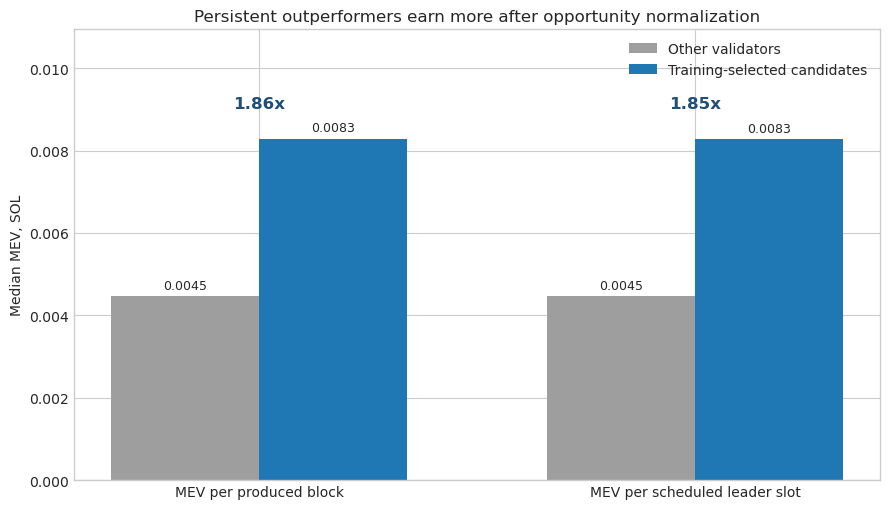

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

labels = ["MEV per produced block", "MEV per scheduled leader slot"]
other = [
    metrics["other_median_mev_per_produced_block"],
    metrics["other_median_mev_per_scheduled_slot"],
]
candidate = [
    metrics["candidate_median_mev_per_produced_block"],
    metrics["candidate_median_mev_per_scheduled_slot"],
]
ratios = [metrics["candidate_block_ratio"], metrics["candidate_slot_ratio"]]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.2))
bars_other = ax.bar(x - width / 2, other, width, label="Other validators", color="#9E9E9E")
bars_candidate = ax.bar(x + width / 2, candidate, width, label="Training-selected candidates", color="#1F77B4")

for bars in [bars_other, bars_candidate]:
    for bar in bars:
        val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.00018, f"{val:.4f}", ha="center", fontsize=9)

for i, ratio in enumerate(ratios):
    ax.text(i, max(other[i], candidate[i]) + 0.00075, f"{ratio:.2f}x", ha="center", fontsize=12, fontweight="bold", color="#1F4E78")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Median MEV, SOL")
ax.set_title("Persistent outperformers earn more after opportunity normalization")
ax.legend(frameon=False)
ax.set_ylim(0, max(candidate) * 1.32)
plt.tight_layout()
plt.show()


## Key plot 2 - mechanism proxies

The next question is what explains the edge. The available public data does not expose the private searcher-validator graph directly, so the mechanism section compares observable proxy families. Order-flow/searcher-flow is the most informative family in the tournament. Landed-execution and latency/infra proxies add signal, but less. Entity/vertical-integration evidence is directionally useful but still measured too coarsely to be the main explanation.


,mechanism,evidence_strength,incremental_r2_vs_stake_baseline,r2_loss_when_dropped_from_full,candidate_attenuation_vs_stake_baseline,status
0,Latency / infra / reliability,partial / indirect,0.039286,0.011629,-0.020472,partially tested
1,Private order-flow / searcher-flow,strongest among available proxies,0.063484,0.030987,-0.102965,strongest current proxy family
2,Bundle outcome / landed execution,partial / landed-only,0.045148,0.014281,-0.524571,partially tested
3,Entity / vertical integration,weak / suggestive,0.017143,0.013075,0.096508,weak proxy only


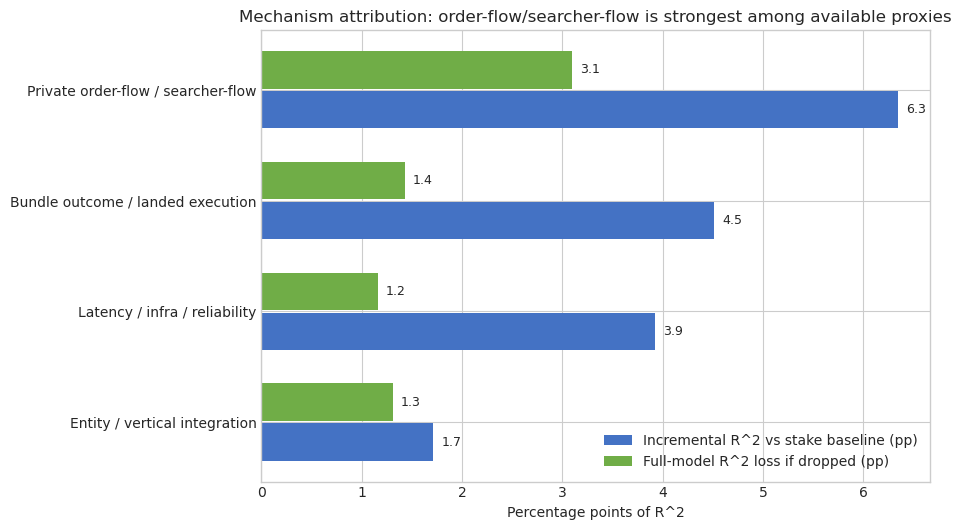

In [4]:
mechanism_display = attrib[[
    "mechanism",
    "evidence_strength",
    "incremental_r2_vs_stake_baseline",
    "r2_loss_when_dropped_from_full",
    "candidate_attenuation_vs_stake_baseline",
    "status",
]].copy()

display(mechanism_display)

plot_df = attrib.sort_values("incremental_r2_vs_stake_baseline").copy()
plot_df["incremental_pp"] = plot_df["incremental_r2_vs_stake_baseline"] * 100
plot_df["drop_loss_pp"] = plot_df["r2_loss_when_dropped_from_full"] * 100

fig, ax = plt.subplots(figsize=(9.5, 5.4))
y = np.arange(len(plot_df))
ax.barh(y - 0.18, plot_df["incremental_pp"], height=0.34, label="Incremental R^2 vs stake baseline (pp)", color="#4472C4")
ax.barh(y + 0.18, plot_df["drop_loss_pp"], height=0.34, label="Full-model R^2 loss if dropped (pp)", color="#70AD47")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["mechanism"])
ax.set_xlabel("Percentage points of R^2")
ax.set_title("Mechanism attribution: order-flow/searcher-flow is strongest among available proxies")
ax.legend(frameon=False, loc="lower right")

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.incremental_pp + 0.08, i - 0.18, f"{row.incremental_pp:.1f}", va="center", fontsize=9)
    ax.text(row.drop_loss_pp + 0.08, i + 0.18, f"{row.drop_loss_pp:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## Validity checks

The main risk is confusing size with skill: large validators naturally have more stake, more slots, and more chances to earn MEV. The checks below pressure-test that concern. They show that the persistent edge is still visible after normalizing by produced blocks, scheduled leader slots, and the final observable proxy set.


In [5]:
validity_rows = []

validity_rows.append({
    "Check": "Completed epochs",
    "Result": metrics["completed_epochs"],
    "Interpretation": "Uses ten completed epochs and excludes the current incomplete epoch.",
})
validity_rows.append({
    "Check": "Final benchmark sample",
    "Result": f"N={int(s['benchmark_n'])}",
    "Interpretation": "Final sample-preserving model is comparable to v20 and avoids a redundant skipped-slots proxy with missing values.",
})
validity_rows.append({
    "Check": "Final benchmark fit",
    "Result": f"R^2={s['benchmark_r_squared']:.3f}, adjusted R^2={s['benchmark_adj_r_squared']:.3f}",
    "Interpretation": "High-fit benchmark used for mechanism attribution.",
})
validity_rows.append({
    "Check": "Candidate coefficient",
    "Result": f"coef={s['benchmark_candidate_coef']:.3f}, p={s['benchmark_candidate_p']:.4f}",
    "Interpretation": "Persistent candidate edge remains visible after observable controls.",
})
validity_rows.append({
    "Check": "Data-loss audit",
    "Result": "; ".join(audit["finding"].astype(str).head(4)),
    "Interpretation": "No validator-row loss or key mismatch in the local diagnostic.",
})
validity_rows.append({
    "Check": "v20-to-v21 drift",
    "Result": "; ".join(drift["status"].astype(str).unique()),
    "Interpretation": "The final v21 result stays within tolerance of the older v20 benchmark and preserves the same mechanism ranking.",
})

cjk = re.compile(r"[\u4e00-\u9fff]")
english_only = True
for path in [FULL_NOTEBOOK, DATA_DOC, API_DOC]:
    if path.exists() and cjk.search(path.read_text(encoding="utf-8", errors="ignore")):
        english_only = False
with zipfile.ZipFile(V21_XLSX) as zf:
    for name in zf.namelist():
        if name.endswith(".xml") and cjk.search(zf.read(name).decode("utf-8", errors="ignore")):
            english_only = False
            break
validity_rows.append({
    "Check": "English-only deliverables",
    "Result": english_only,
    "Interpretation": "The v21 notebook, workbook, and companion docs were scanned for Chinese characters.",
})

validity = pd.DataFrame(validity_rows)
display(validity)

assert int(s["benchmark_n"]) == 411
assert s["benchmark_r_squared"] > 0.80
assert set(drift["status"]).issubset({"WITHIN_TOLERANCE", "SAME"})
assert english_only is True


,Check,Result,Interpretation
0,Completed epochs,983-992,Uses ten completed epochs and excludes the cur...
1,Final benchmark sample,N=411,Final sample-preserving model is comparable to...
2,Final benchmark fit,"R^2=0.816, adjusted R^2=0.781",High-fit benchmark used for mechanism attribut...
3,Candidate coefficient,"coef=0.316, p=0.0014",Persistent candidate edge remains visible afte...
4,Data-loss audit,no row loss in local diagnostic; same column c...,No validator-row loss or key mismatch in the l...
5,v20-to-v21 drift,WITHIN_TOLERANCE; SAME,The final v21 result stays within tolerance of...
6,English-only deliverables,True,"The v21 notebook, workbook, and companion docs..."


## Final interpretation and data boundary

The main result is clear: **Jito is broadly stake-proportional at the aggregate level, but there is a persistent validator-level extraction edge that stake and opportunity do not fully explain.**

The aggregate picture matters because it prevents the wrong conclusion: high MEV concentration alone is not enough to call the auction structurally uncompetitive. Large validators receive a large share of MEV, but they also have more stake and more leader opportunities.

The stronger evidence comes from the validator-efficiency results. The persistent-outperformer screen identifies **57 validators**. In the holdout period, those validators earn about **1.86x** the median MEV per produced block and **1.85x** the median MEV per scheduled leader slot. In the final benchmark model, the fit reaches **R^2 = 0.816**, and the candidate indicator remains positive and statistically significant after the full observable proxy set. That is the core evidence that the edge is not just stake, block count, or scheduled opportunity.

For mechanism, the strongest signal is **order-flow/searcher-flow**. It has the highest module-only explanatory power, adds the most R^2 over the stake baseline, and causes the largest loss of R^2 when removed from the full model. Landed-execution quality and infra/reliability also contribute, but they are secondary in the current tournament. Entity/vertical integration remains suggestive because the available identity mapping is still too coarse.

### What I would stake on

**The Jito auction is competitive in the broad stake-weighted sense, but not fully competitive at the validator-efficiency level.** The data shows a persistent validator-specific extraction edge. The best-supported explanation from the variables we can observe is an order-flow/searcher-flow advantage, with execution quality and infra/reliability as supporting channels.

### Data boundary

The current endpoints are strong enough to show the persistent edge and to rank observable mechanism proxies. They are not granular enough to name the exact private channel behind the edge. To upgrade the mechanism claim from "strongly consistent with order-flow/searcher-flow advantage" to direct causal evidence, the next data layer would need bundle IDs, searcher identity, validator-searcher pairing history, relay timestamps, raw latency distributions, and better operator/ownership mapping.

### Files behind this short notebook

- `clean_analysis_reviewed_improved_v21.ipynb`: full reproducible notebook.
- `jito_analysis_reviewed_improved_v21.xlsx`: final tables, dashboard, mechanism attribution, and validity checks.
- `clean_analysis_reviewed_improved_v21_data_variables.md`: variable definitions and construction notes.
- `clean_analysis_reviewed_improved_v21_api_acquisition.md`: API acquisition notes and limitations.


## Appendix: Original statistical tables

The tables below are the statistical backbone for the memo. They are kept in the appendix so the main write-up can stay answer-first, while still giving the reader the exact model-fit numbers behind the conclusion.

### Table A1. Main model statistics

| Model | N | Variables | R^2 | Adjusted R^2 | Delta R^2 vs previous | Candidate coefficient | Candidate p-value | Interpretation |
|---|---:|---:|---:|---:|---:|---:|---:|---|
| Opportunity controls only | 411 | 3 | 0.164 | 0.158 |  | 0.687 | 9.985e-26 | Baseline: candidates strongly outperform before richer controls. |
| Opportunity + stake-side controls | 411 | 10 | 0.702 | 0.695 | 0.538 | 0.257 | 1.572e-08 | Stake/delegator variables explain a large share of variation, but not all of the candidate edge. |
| Final benchmark with all observable proxies | 411 | 65 | 0.816 | 0.781 | 0.113 | 0.316 | 0.00143 | High-fit benchmark; the candidate edge remains statistically visible after the full proxy set. |

**How to read Table A1:** model fit rises from **R^2 = 0.164** with only opportunity controls to **R^2 = 0.816** in the final benchmark. The candidate coefficient remains positive and statistically significant, which is the main evidence that the edge is not fully explained by stake, blocks, or scheduled opportunity.

### Table A2. Four mechanism-proxy statistics

| Mechanism proxy family | Variables | Module-only R^2 | R^2 when added to stake baseline | Incremental R^2 vs stake baseline | R^2 loss if dropped from full model | Candidate attenuation | Evidence read |
|---|---:|---:|---:|---:|---:|---:|---|
| Latency / infra / reliability | 11 | 0.346 | 0.742 | 0.039 | 0.012 | -0.020 | Partial / indirect |
| Private order-flow / searcher-flow | 18 | 0.501 | 0.766 | 0.063 | 0.031 | -0.103 | Strongest among available proxies |
| Bundle outcome / landed execution | 18 | 0.350 | 0.748 | 0.045 | 0.014 | -0.525 | Partial / landed-only |
| Entity / vertical integration | 6 | 0.251 | 0.720 | 0.017 | 0.013 | 0.097 | Weak / suggestive |

**How to read Table A2:** order-flow/searcher-flow is the strongest mechanism proxy family: it has the highest module-only R^2, the largest incremental R^2 over the stake baseline, and the largest R^2 loss when removed from the full model. That is why the report treats it as the leading observable explanation. The conclusion remains conservative because these are proxies, not direct observations of private relationships or latency.
